# Phase 3a — Spark analysis

Reads the reviews ingested into HDFS in phase 1 and explores how playtime
relates to whether a player recommends a game, and how that relationship
changes with the game's price.

Requires HDFS to be running (`start-dfs.sh`, `start-yarn.sh`).

In [1]:
import getpass

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

In [2]:
USER = getpass.getuser()
HDFS_BASE = f"hdfs://localhost:9000/user/{USER}/steam"

INPUT_PATH = f"{HDFS_BASE}/streaming_input/*.csv"
MAPREDUCE_OUTPUT = f"{HDFS_BASE}/output/recommendation_by_playtime/part-*"

spark = (
    SparkSession.builder
    .appName("steam-reviews-analysis")
    .master("local[*]")
    # the default driver memory is tight once the data is cached
    .config("spark.driver.memory", "4g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
spark

26/09/08 21:09:48 WARN Utils: Your hostname, luca-Katana-15-B13VFK resolves to a loopback address: 127.0.1.1; using 192.168.1.18 instead (on interface wlo1)
26/09/08 21:09:48 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/08 21:09:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Loading the data

Each ingested chunk carries its own header, which Spark skips automatically
when `header=True`.

In [3]:
reviews = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(INPUT_PATH)
)

reviews = reviews.cache()

print(f"rows: {reviews.count():,}")
reviews.printSchema()

[Stage 4:>                                                        (0 + 16) / 17]

rows: 500,000
root
 |-- app_id: integer (nullable = true)
 |-- helpful: integer (nullable = true)
 |-- funny: integer (nullable = true)
 |-- date: date (nullable = true)
 |-- is_recommended: boolean (nullable = true)
 |-- hours: double (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- review_id: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- date_release: date (nullable = true)
 |-- win: boolean (nullable = true)
 |-- mac: boolean (nullable = true)
 |-- linux: boolean (nullable = true)
 |-- rating: string (nullable = true)
 |-- positive_ratio: integer (nullable = true)
 |-- user_reviews: integer (nullable = true)
 |-- price_final: double (nullable = true)
 |-- price_original: double (nullable = true)
 |-- discount: double (nullable = true)
 |-- steam_deck: boolean (nullable = true)
 |-- price_bucket: string (nullable = true)



In [4]:
reviews.select(
    "app_id", "title", "hours", "is_recommended", "price_final", "price_bucket", "date"
).show(5, truncate=False)

+------+--------------------------------+-----+--------------+-----------+------------+----------+
|app_id|title                           |hours|is_recommended|price_final|price_bucket|date      |
+------+--------------------------------+-----+--------------+-----------+------------+----------+
|306130|The Elder Scrolls® Online       |558.5|true          |20.0       |mid         |2020-08-19|
|244850|Space Engineers                 |52.7 |true          |20.0       |mid         |2020-08-19|
|730   |Counter-Strike: Global Offensive|823.5|true          |15.0       |mid         |2020-08-19|
|730   |Counter-Strike: Global Offensive|614.7|true          |15.0       |mid         |2020-08-19|
|306130|The Elder Scrolls® Online       |10.0 |false         |20.0       |mid         |2020-08-19|
+------+--------------------------------+-----+--------------+-----------+------------+----------+
only showing top 5 rows



## Playtime buckets

The same thresholds used by the MapReduce mapper, so that the two engines
can be compared directly.

In [5]:
def with_playtime_bucket(df, hours_col="hours", out_col="playtime_bucket"):
    """Add a discrete playtime bucket column, matching the mapper's logic."""
    hours = F.col(hours_col)
    return df.withColumn(
        out_col,
        F.when(hours < 1, "0-1h")
        .when(hours < 5, "1-5h")
        .when(hours < 20, "5-20h")
        .when(hours < 100, "20-100h")
        .otherwise("100h+"),
    )


# Explicit ordering, since the buckets are strings and would otherwise
# sort lexicographically ("100h+" before "20-100h")
BUCKET_ORDER = ["0-1h", "1-5h", "5-20h", "20-100h", "100h+"]

reviews = with_playtime_bucket(reviews)
reviews.groupBy("playtime_bucket").count().show()

+---------------+------+
|playtime_bucket| count|
+---------------+------+
|           0-1h|  6626|
|        20-100h|158660|
|           1-5h| 18484|
|          100h+|250650|
|          5-20h| 65580|
+---------------+------+



## Cross-checking the MapReduce result

The MapReduce job already computed the recommendation rate per playtime
bucket. Recomputing it in Spark and comparing the two outputs verifies that
both engines agree on the same data.

In [6]:
spark_rates = (
    reviews
    .groupBy("playtime_bucket")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.col("is_recommended").cast("int")).alias("recommended"),
    )
    .withColumn("rate", F.round(F.col("recommended") / F.col("total"), 4))
)

spark_rates.orderBy(
    F.expr(f"array_position(array{tuple(BUCKET_ORDER)}, playtime_bucket)")
).show()

[Stage 12:==========================================>             (13 + 4) / 17]

+---------------+------+-----------+------+
|playtime_bucket| total|recommended|  rate|
+---------------+------+-----------+------+
|           0-1h|  6626|       2326| 0.351|
|           1-5h| 18484|      10625|0.5748|
|          5-20h| 65580|      53913|0.8221|
|        20-100h|158660|     137418|0.8661|
|          100h+|250650|     218341|0.8711|
+---------------+------+-----------+------+



In [7]:
# The MapReduce output is tab-separated with no header
mr_rates = (
    spark.read
    .option("sep", "\t")
    .option("header", False)
    .csv(MAPREDUCE_OUTPUT)
    .toDF("playtime_bucket", "mr_total", "mr_recommended", "mr_rate")
    .select(
        "playtime_bucket",
        F.col("mr_total").cast("long"),
        F.col("mr_recommended").cast("long"),
        F.col("mr_rate").cast("double"),
    )
)

comparison = (
    spark_rates.join(mr_rates, on="playtime_bucket")
    .withColumn("total_matches", F.col("total") == F.col("mr_total"))
    .withColumn("rate_diff", F.abs(F.col("rate") - F.col("mr_rate")))
)

comparison.select(
    "playtime_bucket", "total", "mr_total", "total_matches", "rate", "mr_rate", "rate_diff"
).show()

mismatches = comparison.filter(~F.col("total_matches") | (F.col("rate_diff") > 0.001)).count()
print("MapReduce and Spark agree" if mismatches == 0 else f"WARNING: {mismatches} mismatching buckets")

+---------------+------+--------+-------------+------+-------+---------+
|playtime_bucket| total|mr_total|total_matches|  rate|mr_rate|rate_diff|
+---------------+------+--------+-------------+------+-------+---------+
|           0-1h|  6626|    6626|         true| 0.351|  0.351|      0.0|
|        20-100h|158660|  158660|         true|0.8661| 0.8661|      0.0|
|           1-5h| 18484|   18484|         true|0.5748| 0.5748|      0.0|
|          100h+|250650|  250650|         true|0.8711| 0.8711|      0.0|
|          5-20h| 65580|   65580|         true|0.8221| 0.8221|      0.0|
+---------------+------+--------+-------------+------+-------+---------+

MapReduce and Spark agree


## Playtime and price

Does the effect of playtime on the recommendation rate depend on how much
the game costs?

In [8]:
by_playtime_price = (
    reviews
    .groupBy("price_bucket", "playtime_bucket")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.col("is_recommended").cast("int")).alias("recommended"),
    )
    .withColumn("rate", F.round(F.col("recommended") / F.col("total"), 4))
    # small cells are noisy and would distort the comparison
    .filter(F.col("total") >= 100)
)

by_playtime_price.orderBy("price_bucket", "playtime_bucket").show(50)

+------------+---------------+-----+-----------+------+
|price_bucket|playtime_bucket|total|recommended|  rate|
+------------+---------------+-----+-----------+------+
|        free|           0-1h| 2047|        774|0.3781|
|        free|           1-5h| 4163|       2220|0.5333|
|        free|          100h+|57105|      42794|0.7494|
|        free|        20-100h|25106|      19026|0.7578|
|        free|          5-20h|10470|       7562|0.7223|
|        high|           0-1h| 2481|        753|0.3035|
|        high|           1-5h| 7444|       3910|0.5253|
|        high|          100h+|95505|      86494|0.9056|
|        high|        20-100h|74114|      64032| 0.864|
|        high|          5-20h|30215|      24522|0.8116|
|         low|           0-1h|  211|        116|0.5498|
|         low|           1-5h| 1118|        960|0.8587|
|         low|          100h+| 7998|       7321|0.9154|
|         low|        20-100h| 9369|       8820|0.9414|
|         low|          5-20h| 5096|       4772|

In [9]:
# Same numbers as a pivot, easier to read across price buckets
(
    by_playtime_price
    .groupBy("playtime_bucket")
    .pivot("price_bucket", ["free", "low", "mid", "high"])
    .agg(F.first("rate"))
    .orderBy(F.expr(f"array_position(array{tuple(BUCKET_ORDER)}, playtime_bucket)"))
    .show()
)

+---------------+------+------+------+------+
|playtime_bucket|  free|   low|   mid|  high|
+---------------+------+------+------+------+
|           0-1h|0.3781|0.5498| 0.362|0.3035|
|           1-5h|0.5333|0.8587|0.6138|0.5253|
|          5-20h|0.7223|0.9364|0.8615|0.8116|
|        20-100h|0.7578|0.9414|0.9095| 0.864|
|          100h+|0.7494|0.9154|0.9077|0.9056|
+---------------+------+------+------+------+



## How much do recommenders actually play?

Comparing average playtime between players who recommended a game and those
who did not, split by price bucket.

In [10]:
hours_by_outcome = (
    reviews
    .groupBy("price_bucket", "is_recommended")
    .agg(
        F.count("*").alias("reviews"),
        F.round(F.avg("hours"), 1).alias("avg_hours"),
        F.round(F.expr("percentile_approx(hours, 0.5)"), 1).alias("median_hours"),
    )
    .orderBy("price_bucket", "is_recommended")
)

hours_by_outcome.show()

[Stage 38:>                                                         (0 + 1) / 1]

+------------+--------------+-------+---------+------------+
|price_bucket|is_recommended|reviews|avg_hours|median_hours|
+------------+--------------+-------+---------+------------+
|        free|         false|  26515|    227.9|       120.8|
|        free|          true|  72376|    253.1|       147.7|
|        high|         false|  30048|    117.8|        39.4|
|        high|          true| 179711|    185.1|        93.0|
|         low|         false|   1803|    155.1|        57.2|
|         low|          true|  21989|    132.1|        51.1|
|         mid|         false|  19011|    185.6|        68.9|
|         mid|          true| 148547|    219.5|       121.5|
+------------+--------------+-------+---------+------------+



## Trend over time

Whether the overall recommendation rate has drifted across years.

In [11]:
by_year = (
    reviews
    .withColumn("year", F.year("date"))
    .filter(F.col("year").isNotNull())
    .groupBy("year")
    .agg(
        F.count("*").alias("total"),
        F.sum(F.col("is_recommended").cast("int")).alias("recommended"),
        F.round(F.avg("hours"), 1).alias("avg_hours"),
    )
    .withColumn("rate", F.round(F.col("recommended") / F.col("total"), 4))
    # years with very few reviews would swing wildly
    .filter(F.col("total") >= 500)
    .orderBy("year")
)

by_year.show(30)

[Stage 39:===>                                                    (1 + 16) / 17]

+----+------+-----------+---------+------+
|year| total|recommended|avg_hours|  rate|
+----+------+-----------+---------+------+
|2013|  2475|       2366|    273.1| 0.956|
|2014|  9752|       9045|    264.0|0.9275|
|2015| 13335|      10691|    274.9|0.8017|
|2016| 22689|      17389|    252.4|0.7664|
|2017| 26314|      19079|    270.6|0.7251|
|2018| 24618|      18928|    265.0|0.7689|
|2019| 39449|      34516|    269.1| 0.875|
|2020| 90728|      80119|    216.9|0.8831|
|2021|105117|      92369|    194.3|0.8787|
|2022|165148|     137763|    141.6|0.8342|
+----+------+-----------+---------+------+



## Visualisations

The aggregates are small (tens of rows), so collecting them to pandas for
plotting is safe.

In [12]:
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (9, 5)

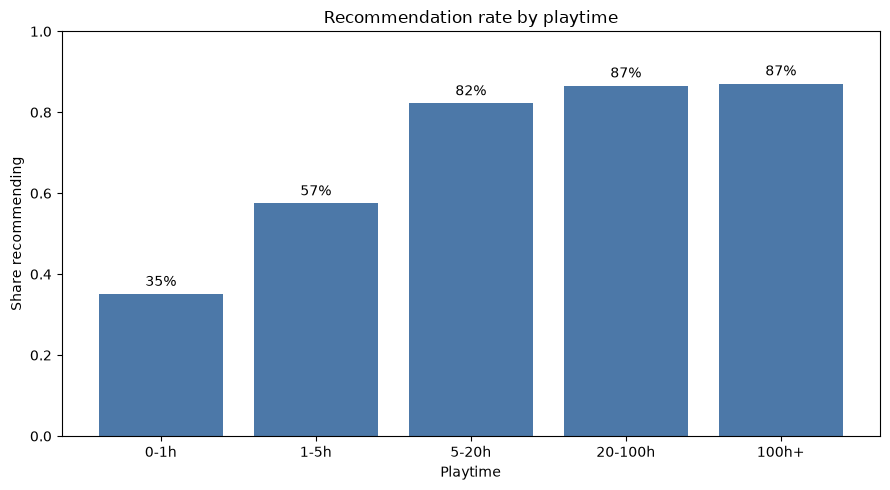

In [13]:
pdf = spark_rates.toPandas()
pdf["playtime_bucket"] = pdf["playtime_bucket"].astype("category").cat.set_categories(BUCKET_ORDER)
pdf = pdf.sort_values("playtime_bucket")

ax = plt.subplots()[1]
ax.bar(pdf["playtime_bucket"].astype(str), pdf["rate"], color="#4c78a8")
ax.set_ylim(0, 1)
ax.set_xlabel("Playtime")
ax.set_ylabel("Share recommending")
ax.set_title("Recommendation rate by playtime")
for x, y in zip(pdf["playtime_bucket"].astype(str), pdf["rate"]):
    ax.text(x, y + 0.02, f"{y:.0%}", ha="center")
plt.tight_layout()
plt.show()

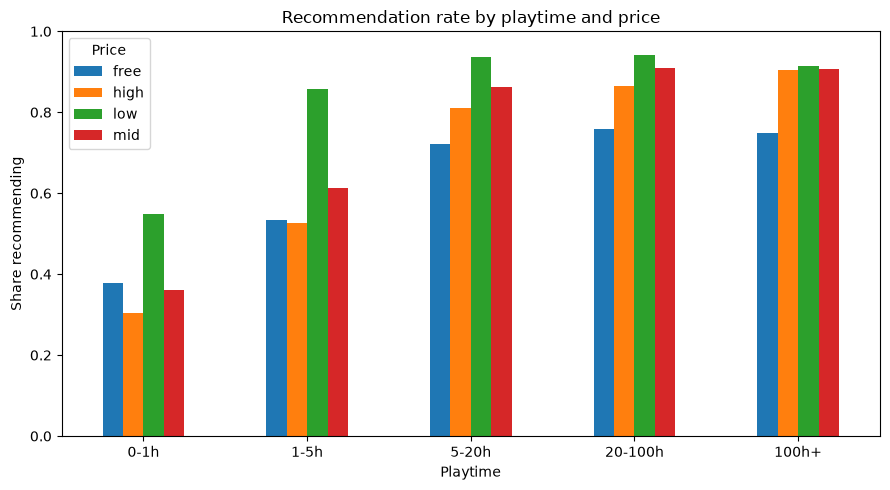

In [14]:
pivot = (
    by_playtime_price.toPandas()
    .pivot(index="playtime_bucket", columns="price_bucket", values="rate")
    .reindex(BUCKET_ORDER)
)

ax = pivot.plot(kind="bar", ylim=(0, 1), rot=0)
ax.set_xlabel("Playtime")
ax.set_ylabel("Share recommending")
ax.set_title("Recommendation rate by playtime and price")
ax.legend(title="Price")
plt.tight_layout()
plt.show()

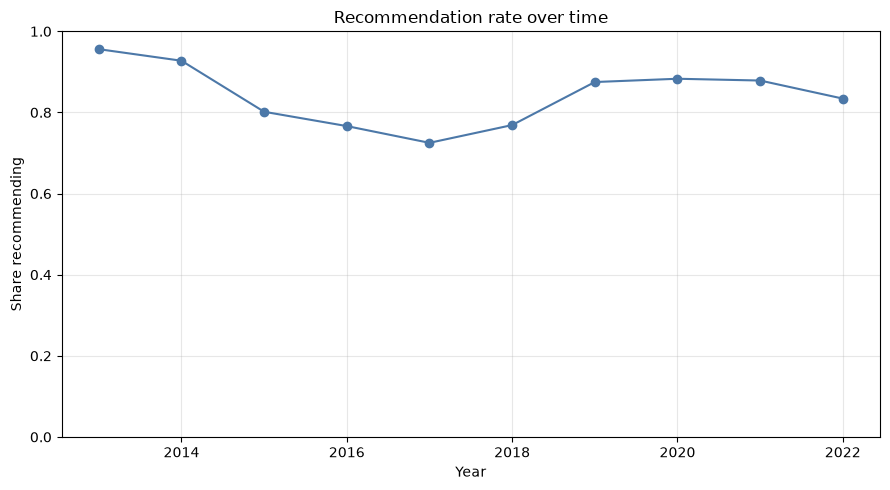

In [15]:
years = by_year.toPandas().sort_values("year")

fig, ax = plt.subplots()
ax.plot(years["year"], years["rate"], marker="o", color="#4c78a8")
ax.set_ylim(0, 1)
ax.set_xlabel("Year")
ax.set_ylabel("Share recommending")
ax.set_title("Recommendation rate over time")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()